# BC02 — Analyse exploratoire des données

**Objectif RNCP :** regarder les données *avant* de modéliser — les résumer, les visualiser, et
vérifier avec des tests statistiques que ce qu'on croit voir n'est pas un effet du hasard.

On lit les 3 fichiers produits par BC01 (`donnees/traitees/*.parquet`) et on répond à 3 questions :

1. Les observations suivent-elles un **rythme saisonnier** cohérent avec un oiseau migrateur ?
2. **Où** les oiseaux sont-ils observés dans la région ?
3. La **météo** semble-t-elle liée à la présence des oiseaux ?

Le notebook est découpé en **étapes numérotées** : chaque étape charge → calcule → visualise →
interprète, et se termine par un petit **bilan**. Aucun modèle n'est entraîné ici : c'est le rôle
de BC03.

## ÉTAPE 0 — Préparation

In [1]:
import sys
from pathlib import Path

# Rend le package commun/ importable, quel que soit le dossier de lancement
_racine = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "commun").is_dir())
sys.path.insert(0, str(_racine))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from scipy.stats import chi2_contingency

%matplotlib inline
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
pd.set_option("display.width", 120)

from commun.config import REPERTOIRE_DONNEES_TRAITEES, ESPECES, ZONE_GEOGRAPHIQUE

print("Racine du projet :", _racine)

Racine du projet : C:\Users\rasmi\Projects\projet_rncp\oiseaux_migrateurs_npdc


## ÉTAPE 1 — Charger et découvrir les 3 tables de BC01

BC01 a produit 3 fichiers Parquet. On les charge tels quels et on regarde leur forme
(`shape`), leurs premières lignes (`head`) et le type de chaque colonne (`dtypes`).

In [2]:
# --- 1.1 Chargement ---
df_obs = pd.read_parquet(REPERTOIRE_DONNEES_TRAITEES / "observations_nettoyees.parquet")
df_grille = pd.read_parquet(REPERTOIRE_DONNEES_TRAITEES / "grille_presence_hebdo.parquet")
df_meteo = pd.read_parquet(REPERTOIRE_DONNEES_TRAITEES / "meteo_processed.parquet")

print(f"observations_nettoyees : {df_obs.shape[0]:>7,} lignes x {df_obs.shape[1]} colonnes".replace(",", " "))
print(f"grille_presence_hebdo  : {df_grille.shape[0]:>7,} lignes x {df_grille.shape[1]} colonnes".replace(",", " "))
print(f"meteo_processed        : {df_meteo.shape[0]:>7,} lignes x {df_meteo.shape[1]} colonnes".replace(",", " "))

observations_nettoyees :  39 986 lignes x 9 colonnes
grille_presence_hebdo  : 681 408 lignes x 7 colonnes
meteo_processed        :   2 192 lignes x 8 colonnes


In [3]:
# --- 1.2 Aperçu de chaque table ---
print("OBSERVATIONS (1 ligne = 1 signalement d'oiseau)")
print("  période :", df_obs["date_observation"].min().date(), "->", df_obs["date_observation"].max().date())
print("  espèces :", df_obs["espece"].nunique(), "|", list(df_obs["espece"].unique()))
display(df_obs.head(3))

print("\nGRILLE présence/absence (1 ligne = 1 semaine x 1 maille x 1 espèce)")
print(f"  présences : {df_grille['presence'].sum():,} sur {len(df_grille):,} "
      f"({df_grille['presence'].mean()*100:.1f} %)".replace(",", " "))
display(df_grille.head(3))

print("\nMÉTÉO journalière (1 ligne = 1 jour, moyenne région)")
display(df_meteo.head(3))

OBSERVATIONS (1 ligne = 1 signalement d'oiseau)
  période : 2019-01-01 -> 2024-12-31
  espèces : 4 | ['hirondelle_rustique', 'cigogne_blanche', 'martinet_noir', 'bergeronnette_printaniere']


,espece,nom_scientifique,date_observation,latitude,longitude,precision_coordinate,pays,source,id_gbif
0,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-08,51.4,3.9,5000.0,Netherlands,GBIF,4881884490
1,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-02,51.4,3.9,5000.0,Netherlands,GBIF,4885294867
2,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-05,51.4,3.9,5000.0,Netherlands,GBIF,4885677627



GRILLE présence/absence (1 ligne = 1 semaine x 1 maille x 1 espèce)
  présences : 15 903 sur 681 408 (2.3 %)


,annee,semaine,espece,lat_discrete,lon_discrete,nombre_observations,presence
0,2019,1,hirondelle_rustique,51.4,3.9,0.0,0
1,2019,1,hirondelle_rustique,51.4,2.6,0.0,0
2,2019,1,hirondelle_rustique,51.4,3.5,0.0,0



MÉTÉO journalière (1 ligne = 1 jour, moyenne région)


,date,temperature_max,temperature_min,temperature_moyenne,precipitation_sum,vent_max,humidite_moyenne,pression_moyenne
0,2019-01-01,8.8,5.0,7.4,0.2,18.8,87,1033.6
1,2019-01-02,6.9,4.2,5.6,0.1,17.1,72,1039.5
2,2019-01-03,5.7,2.4,4.2,0.0,10.2,81,1041.2


**Bilan étape 1.** Trois granularités différentes : les **observations** sont éparses (là où
quelqu'un a regardé), la **grille** est complète (toutes les semaines × mailles, avec un 0/1), la
**météo** est quotidienne pour toute la région. BC02 croise ces trois tables ; BC03 les fusionnera
pour entraîner un modèle.

## ÉTAPE 2 — Saisonnalité : les oiseaux arrivent-ils quand on s'y attend ?

Pour chaque espèce, on compte les observations **par mois**. Un vrai migrateur doit montrer un pic
d'arrivée puis un creux hivernal. Les traits verts marquent les mois d'arrivée **attendus** d'après
la littérature (renseignés dans `commun/config.py`) : s'ils tombent sur les pics réels, les données
GBIF sont cohérentes avec les connaissances de terrain.

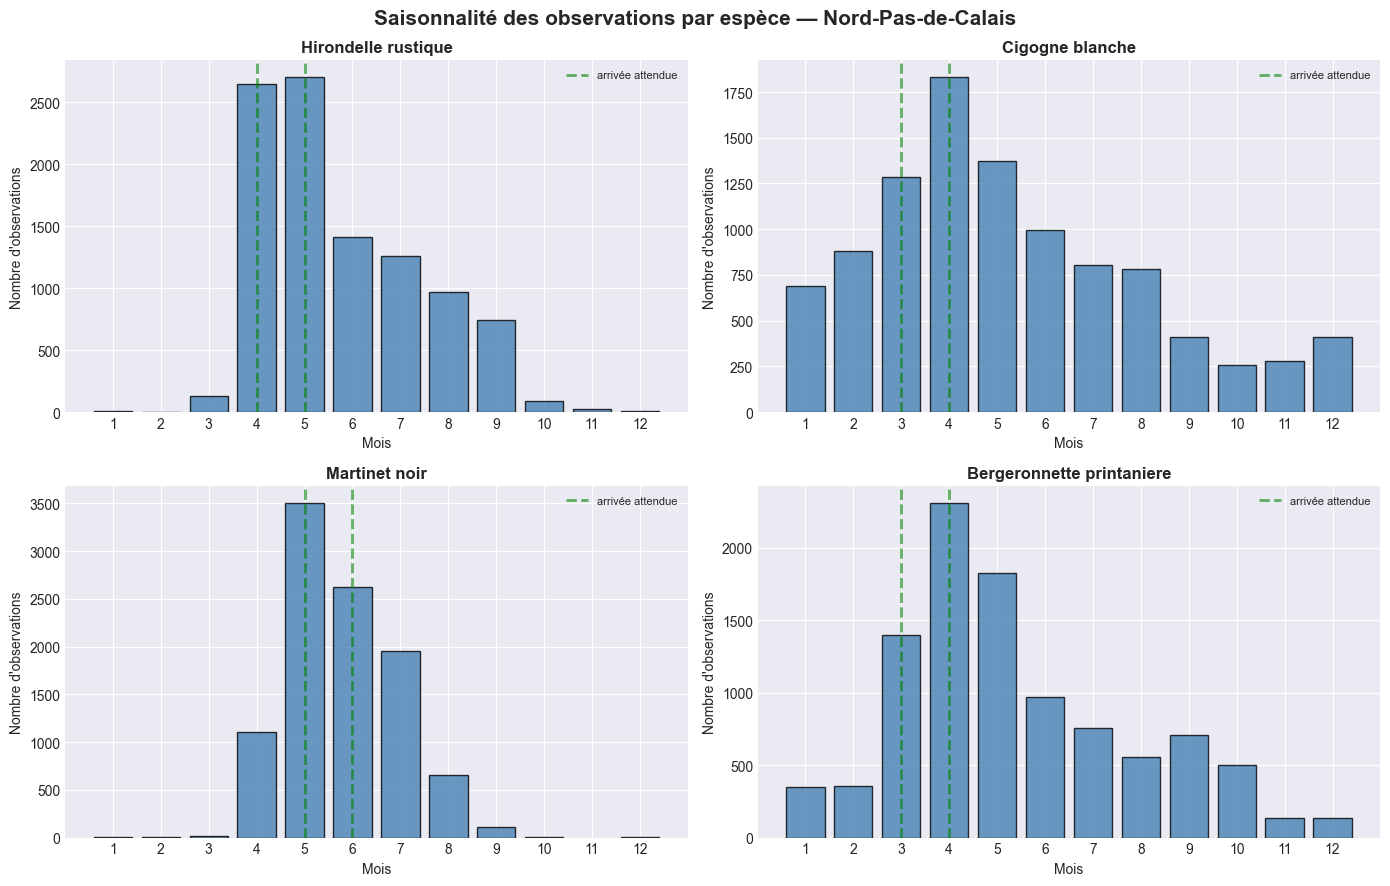

In [4]:
# --- 2.1 Observations par mois et par espèce ---
df_obs["mois"] = pd.to_datetime(df_obs["date_observation"]).dt.month
saison = df_obs.groupby(["mois", "espece"]).size().reset_index(name="nb_observations")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Saisonnalité des observations par espèce — Nord-Pas-de-Calais", fontsize=15, fontweight="bold")

for i, (cle, infos) in enumerate(ESPECES.items()):
    ax = axes[i // 2, i % 2]
    sous = saison[saison["espece"] == cle]
    ax.bar(sous["mois"], sous["nb_observations"], color="steelblue", alpha=0.8, edgecolor="black")
    for m in infos["mois_arrivee"]:
        ax.axvline(m, color="green", linestyle="--", linewidth=2, alpha=0.6,
                   label="arrivée attendue" if m == infos["mois_arrivee"][0] else None)
    ax.set_title(infos["nom_francais"], fontweight="bold")
    ax.set_xlabel("Mois")
    ax.set_ylabel("Nombre d'observations")
    ax.set_xticks(range(1, 13))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
# --- 2.2 Mois de pic observé vs mois d'arrivée attendu ---
print(f"{'Espèce':<28} {'pic observé':>12} {'arrivée attendue':>20}")
print("-" * 62)
for cle, infos in ESPECES.items():
    sous = saison[saison["espece"] == cle]
    mois_pic = int(sous.loc[sous["nb_observations"].idxmax(), "mois"])
    print(f"{infos['nom_francais']:<28} {('mois ' + str(mois_pic)):>12} {str(infos['mois_arrivee']):>20}")

Espèce                        pic observé     arrivée attendue
--------------------------------------------------------------
Hirondelle rustique                mois 5               [4, 5]
Cigogne blanche                    mois 4               [3, 4]
Martinet noir                      mois 5               [5, 6]
Bergeronnette printaniere          mois 4               [3, 4]


**Bilan étape 2.** Pour les 4 espèces, le pic d'observations tombe au printemps/été, à côté ou sur
les mois d'arrivée attendus. La présence des oiseaux dépend donc **fortement de la période de
l'année** — c'est le premier signal, purement visuel, qu'on confirmera par un test à l'étape 6.

## ÉTAPE 3 — Où observe-t-on les oiseaux ? (carte de densité)

Une carte de chaleur montre les zones où les observations sont les plus concentrées.

In [6]:
centre = [ZONE_GEOGRAPHIQUE.centre_latitude, ZONE_GEOGRAPHIQUE.centre_longitude]
carte = folium.Map(location=centre, zoom_start=9, tiles="OpenStreetMap")
HeatMap(df_obs[["latitude", "longitude"]].values.tolist(), radius=15, blur=25, max_zoom=1).add_to(carte)
folium.CircleMarker(centre, radius=5, color="red", fill=True, popup="Centre NPDC").add_to(carte)
carte

**Bilan étape 3.** Les zones rouges correspondent en général à des sites d'observation
ornithologique connus (zones humides, réserves, littoral). C'est logique : ce sont aussi les
endroits où les naturalistes se rendent le plus. À retenir : les données GBIF reflètent
**l'effort d'observation** autant que la présence réelle — un biais classique de la science
citoyenne, à garder en tête pour l'interprétation de BC03.

## ÉTAPE 4 — Distributions des variables météo

Analyse univariée : pour chaque variable météo on regarde moyenne, écart-type, min, max, et le
nombre de valeurs extrêmes (règle de l'écart interquartile, **IQR**). But : vérifier que les
chiffres sont plausibles pour un climat du Nord de la France.

In [7]:
# --- 4.1 Statistiques descriptives ---
variables_meteo = df_meteo.select_dtypes("number").columns.tolist()
resume = df_meteo[variables_meteo].agg(["mean", "std", "min", "max"]).T

def compter_outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    borne_basse, borne_haute = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((serie < borne_basse) | (serie > borne_haute)).sum())

resume["outliers_iqr"] = [compter_outliers_iqr(df_meteo[v]) for v in variables_meteo]
print(resume.round(2).to_string())

                        mean    std    min     max  outliers_iqr
temperature_max        15.42   6.70   -2.9    38.2             3
temperature_min         7.98   5.40   -7.4    22.3             0
temperature_moyenne    11.61   5.84   -4.9    29.2             0
precipitation_sum       2.17   3.80    0.0    35.4           232
vent_max               21.65   8.43    5.5    62.5            27
humidite_moyenne       78.28   9.54   38.0    98.0            17
pression_moyenne     1015.89  10.19  975.3  1047.6            47


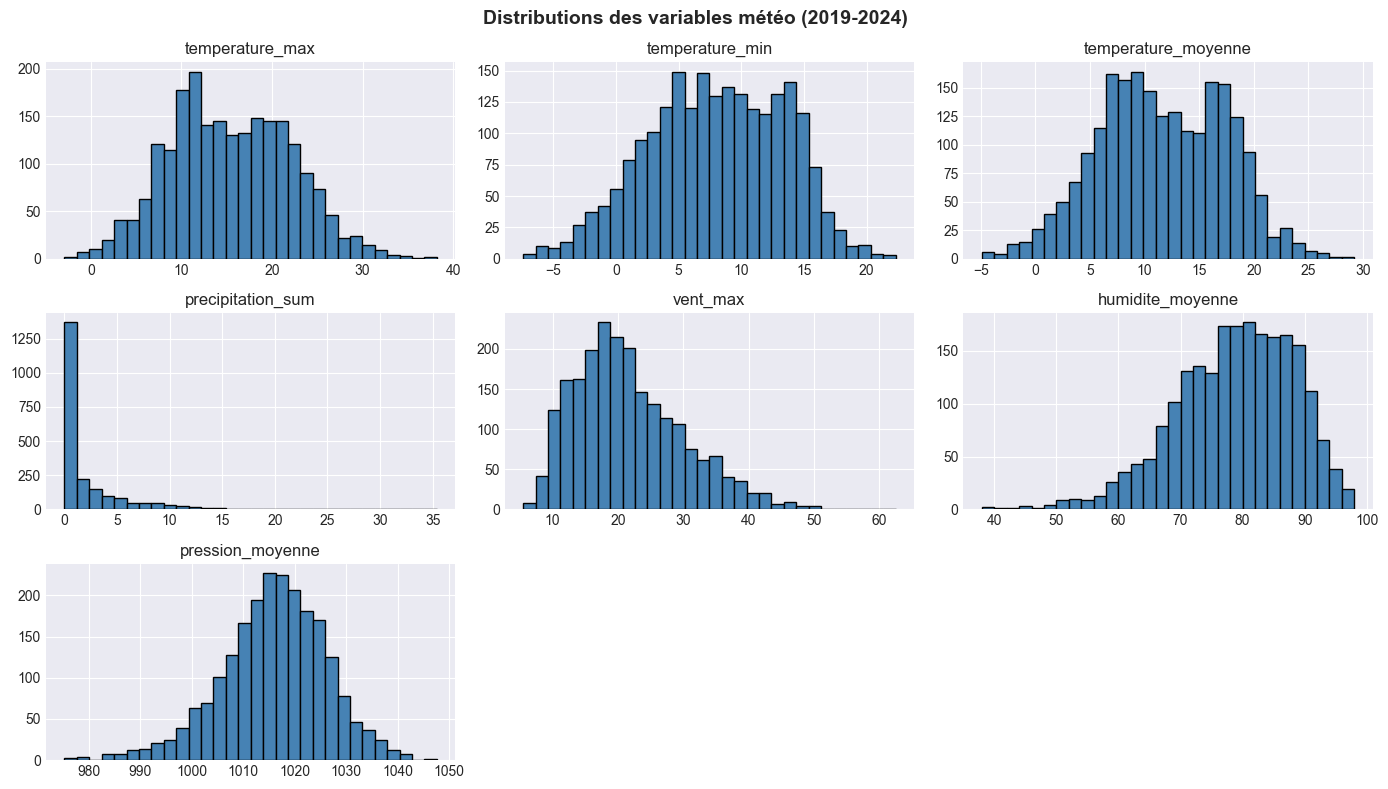

In [8]:
# --- 4.2 Histogrammes ---
df_meteo[variables_meteo].hist(figsize=(14, 8), bins=30, color="steelblue", edgecolor="black")
plt.suptitle("Distributions des variables météo (2019-2024)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Bilan étape 4.** Température maximale moyenne autour de 15 °C, humidité élevée (~78 %), pression
autour de 1015 hPa : cohérent avec un **climat océanique**. Les quelques valeurs extrêmes (fortes
précipitations, coups de vent) sont des événements météo réels, on les garde.

## ÉTAPE 5 — La météo est-elle liée à la présence des oiseaux ?

On calcule la **corrélation** entre chaque variable météo et la colonne `presence`, semaine par
semaine et espèce par espèce. Une corrélation est un nombre entre −1 et +1 :

- proche de **±1** : les deux quantités évoluent ensemble de façon très régulière ;
- proche de **0** : pas de lien linéaire visible.

*Rappel : corrélation ≠ causalité.* Un lien peut venir d'une 3ᵉ cause commune (ici la saison).

In [9]:
# --- 5.1 Fusion : moyenne météo hebdomadaire rattachée à la grille ---
meteo = df_meteo.copy()
meteo["annee"] = pd.to_datetime(meteo["date"]).dt.isocalendar().year.astype(int)
meteo["semaine"] = pd.to_datetime(meteo["date"]).dt.isocalendar().week.astype(int)

variables = ["temperature_max", "temperature_min", "temperature_moyenne",
             "precipitation_sum", "vent_max", "humidite_moyenne", "pression_moyenne"]
variables = [v for v in variables if v in meteo.columns]
meteo_hebdo = meteo.groupby(["annee", "semaine"], as_index=False)[variables].mean()

fusion = df_grille.merge(meteo_hebdo, on=["annee", "semaine"], how="left")
print("Grille + météo hebdomadaire :", fusion.shape)

# --- 5.2 Corrélation météo <-> présence, par espèce ---
correlations = {}
for espece in fusion["espece"].unique():
    sous = fusion[fusion["espece"] == espece]
    correlations[espece] = {v: sous["presence"].corr(sous[v]) for v in variables}

df_corr = pd.DataFrame(correlations).T
df_corr.index = [ESPECES[e]["nom_francais"] for e in df_corr.index]
print(df_corr.round(3).to_string())

Grille + météo hebdomadaire : (681408, 14)


                           temperature_max  temperature_min  temperature_moyenne  precipitation_sum  vent_max  humidite_moyenne  pression_moyenne
Hirondelle rustique                  0.075            0.059                0.070             -0.005    -0.030            -0.053            -0.003
Cigogne blanche                      0.010           -0.007                0.003             -0.017    -0.014            -0.037             0.019
Martinet noir                        0.109            0.087                0.104             -0.011    -0.047            -0.109             0.012
Bergeronnette printaniere            0.026            0.012                0.020             -0.000    -0.013            -0.025             0.002


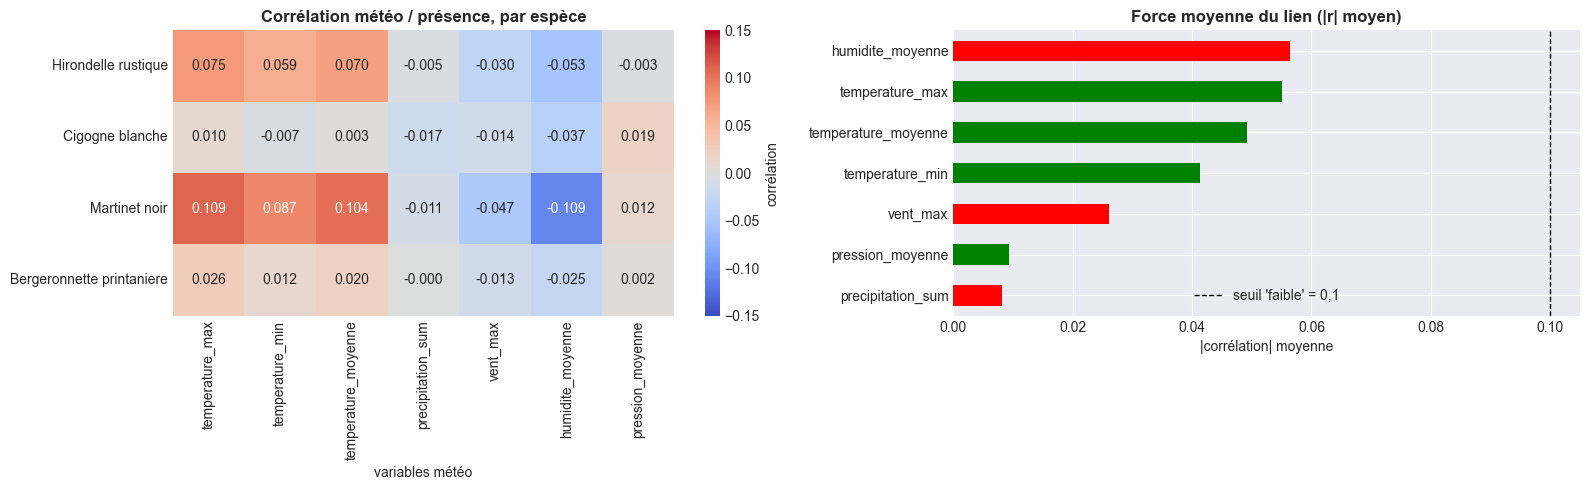

In [10]:
# --- 5.3 Visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df_corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            vmin=-0.15, vmax=0.15, cbar_kws={"label": "corrélation"}, ax=axes[0])
axes[0].set_title("Corrélation météo / présence, par espèce", fontweight="bold")
axes[0].set_xlabel("variables météo")

force = df_corr.abs().mean().sort_values()
couleurs = ["green" if df_corr[v].mean() > 0 else "red" for v in force.index]
force.plot(kind="barh", ax=axes[1], color=couleurs)
axes[1].axvline(0.1, color="black", linestyle="--", linewidth=1, label="seuil 'faible' = 0,1")
axes[1].set_title("Force moyenne du lien (|r| moyen)", fontweight="bold")
axes[1].set_xlabel("|corrélation| moyenne")
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# --- 5.4 Interprétation chiffrée ---
r_max = df_corr.abs().max().max()
print(f"Corrélation la plus forte (en valeur absolue) : {r_max:.3f}")
if r_max < 0.15:
    print("-> Toutes les corrélations sont FAIBLES (|r| < 0,15) : la météo prise")
    print("   isolément n'explique presque pas la présence, semaine par semaine.")
elif r_max < 0.3:
    print("-> Corrélations MODÉRÉES au mieux.")
else:
    print("-> Au moins une corrélation FORTE.")

Corrélation la plus forte (en valeur absolue) : 0.109
-> Toutes les corrélations sont FAIBLES (|r| < 0,15) : la météo prise
   isolément n'explique presque pas la présence, semaine par semaine.


**Bilan étape 5.** Toutes les corrélations sont proches de 0 (au maximum ~0,11 en valeur absolue).
La météo seule n'a **pas de lien linéaire fort** avec la présence. Ça ne veut pas dire qu'elle est
inutile — mais son effet est **beaucoup plus faible que celui de la saison** (étape 2). BC03 devra
donc combiner **météo + semaine + position** pour espérer un modèle utile.

## ÉTAPE 6 — Test du χ² : la saisonnalité est-elle réelle, ou du hasard ?

Le graphique de l'étape 2 est convaincant à l'œil, mais un jury préfère une preuve chiffrée. Le
**test du χ² d'indépendance** répond à : *« le mois d'observation et l'espèce sont-ils liés, ou
leur association pourrait-elle s'expliquer par le simple hasard ? »*

- **H0** (hypothèse nulle) : mois et espèce sont **indépendants** (pas de saisonnalité liée à l'espèce).
- **H1** (hypothèse alternative) : il y a un **lien**.
- Seuil : **α = 0,05**. Si p‑value < 0,05, on rejette H0.

In [12]:
contingence = pd.crosstab(df_obs["espece"], df_obs["mois"])
print("Tableau de contingence (espèce x mois) :")
print(contingence.to_string())

chi2, p_value, ddl, attendus = chi2_contingency(contingence)
print(f"\nchi2 = {chi2:.1f}   |   ddl = {ddl}   |   p-value = {p_value:.2e}")

if p_value < 0.05:
    print("\np-value < 0,05  ->  on REJETTE H0.")
    print("Le lien entre le mois et l'espèce observée est statistiquement SIGNIFICATIF :")
    print("la saisonnalité vue à l'étape 2 n'est pas un artefact du hasard.")
else:
    print("\np-value >= 0,05  ->  on ne peut pas exclure le hasard.")

Tableau de contingence (espèce x mois) :
mois                        1    2     3     4     5     6     7    8    9    10   11   12
espece                                                                                    
bergeronnette_printaniere  349  353  1399  2312  1826   971   756  559  707  498  136  134
cigogne_blanche            689  879  1286  1831  1373   998   803  784  411  258  278  408
hirondelle_rustique          6    1   132  2648  2704  1415  1257  967  747   92   25    5
martinet_noir                4    3    17  1107  3507  2623  1953  655  113    5    0    2

chi2 = 11535.1   |   ddl = 33   |   p-value = 0.00e+00

p-value < 0,05  ->  on REJETTE H0.
Le lien entre le mois et l'espèce observée est statistiquement SIGNIFICATIF :
la saisonnalité vue à l'étape 2 n'est pas un artefact du hasard.


**Bilan étape 6.** p‑value extrêmement petite (≈ 0) → la saisonnalité est **significative**. C'est
la confirmation statistique de ce que montrait l'étape 2.

## Récapitulatif — ce qu'il faut retenir

| Étape | Constat |
|---|---|
| 1. Tables BC01 | 3 granularités : observations éparses, grille présence/absence complète, météo journalière |
| 2. Saisonnalité | Les pics d'observation collent au calendrier biologique attendu → données GBIF crédibles |
| 3. Carte de densité | Concentrations = sites d'observation connus → les données reflètent aussi l'**effort d'observation** |
| 4. Distributions météo | Valeurs plausibles pour un climat océanique, quelques extrêmes légitimes |
| 5. Corrélations | **La météo seule est faiblement corrélée à la présence** (|r| < 0,1) |
| 6. Test du χ² | La **saisonnalité est statistiquement significative** (p ≈ 0) |

**Et après ?** BC03 (Machine Learning) va fusionner grille + météo et entraîner un modèle de
classification. Les deux constats clés de BC02 orientent ce travail : (1) la **période de l'année**
compte plus que la météo brute ; (2) le fort **déséquilibre des classes** de la grille (~2 % de
présences) obligera à lire les métriques avec prudence.

Le script `run.py` de ce bloc rejoue ces mêmes analyses en une commande et **sauvegarde** les
figures dans `outputs/eda/` (`saisonnalite.png`, `distributions_meteo.png`, `carte_densite.html`,
`correlations_meteo.png`).